In [1]:
# TODO:
# 4) PSD (Predictive Sparse Decomposition)

# Begin

In [2]:
# @launchit.collected

In [3]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp

from tqdm.notebook import tqdm

import lark # @launchit.collect

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from model_registry import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect_2
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Setup

In [4]:
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

LOG = Logging.get()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    run_path='',
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/11_cnn',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'run_path': '/home/misha/dev/mine/neurovision/run/11_cnn',
 'self_fname': '/home/misha/dev/mine/neurovision/11_cnn/s4_cnn_01.ipynb',
 'self_name': 's4_cnn_01',
 'subproject_name': '11_cnn',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [5]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN_FEAT_EXTR_MODEL = auto()
    TRAIN_WHOLE_MODEL_CV = auto()
    TEST_ACCURACY = auto()

LAUNCH_GOAL = namedtuple('LaunchGoal', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

METRICS_SUITE = defaultdict(list)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.11_cnn',
 'model_name': 's4_cnn_01',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/11_cnn/s4_cnn_01.ipynb'}


# Hyperparameters

In [6]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    
    @dataclass
    class Images:
        preprocessing: str = None
        
    @dataclass
    class ExtrFeatModelUnit: # spec of CNN
        convolution: str = None # e.g.: 1->64(1)x9, 16->256(2)x9, 1->32(2)x5+bias
        nonlinearity: str = None # any of: None, sigmoid, tanh, ...
        with_gain: bool = None
        rectification: str = None # any of: None, abs, relu
        normalization: str = None # any of: None, LCN(9,2)
        pooling: str = None # e.g.: boxcar(9)->avg(2), boxcar(9)->max(3), max(3)

    @dataclass
    class ExtrFeatModelTraining:
        protocol: str = None # any of: R (random, no refine), R+ (random with refine), PSD (PSD, no refine), PSD+ (PSD with refine)
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        loss: str = None
        sparsity: float = None

    @dataclass
    class LogRegModelUnit: # spec of fully connected feed-forward NN
        items_count: int = None
        nonlinearity: str = None # any of: None, sigmoid, tanh, ...
        dropout: float = None
    
    @dataclass
    class LogRegModelTraining:
        protocol: str = None # any of: R (random, no refine), R+ (random with refine)
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        cv_folds_count: int = None
        
    images: Images = dataclasses.field(default_factory=Images)
    extr_feat_model: list = dataclasses.field(default_factory=list) # of ExtrFeatModelUnit
    extr_feat_model_training: ExtrFeatModelTraining = dataclasses.field(default_factory=ExtrFeatModelTraining)
    log_reg_model: list = dataclasses.field(default_factory=list)  # of LogRegModelUnit
    log_reg_model_training: LogRegModelTraining = dataclasses.field(default_factory=LogRegModelTraining)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.images = Hyperparameters.Images(**hp.images)
        hp.extr_feat_model = list(map(lambda i: Hyperparameters.ExtrFeatModelUnit(**i), hp.extr_feat_model))
        hp.extr_feat_model_training = Hyperparameters.ExtrFeatModelTraining(**hp.extr_feat_model_training)
        hp.log_reg_model = list(map(lambda i: Hyperparameters.LogRegModelUnit(**i), hp.log_reg_model))
        hp.log_reg_model_training = Hyperparameters.LogRegModelTraining(**hp.log_reg_model_training)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42


In [7]:
ExtrFeatModelUnitConvolution = namedtuple('ExtrFeatModelUnitConvolution', 'in_channels_count out_channels_count in_channels_count_per_kernel kernel_size with_bias')

def extr_feat_model_unit_parse_convolution(self):
    r = r'(?P<in_channels_count>\d+)->(?P<out_channels_count>\d+)\((?P<in_channels_count_per_kernel>\d+)\)x(?P<kernel_size>\d+)(?P<with_bias>[+-]bias)?'
    m = re.match(r, self.convolution)
    assert m, self.convolution
    d = m.groupdict()
    return ExtrFeatModelUnitConvolution(
        in_channels_count=int(d['in_channels_count']), 
        out_channels_count=int(d['out_channels_count']), 
        in_channels_count_per_kernel=int(d['in_channels_count_per_kernel']), 
        kernel_size=int(d['kernel_size']),
        with_bias=d['with_bias'] == '+bias',
    )

ExtrFeatModelUnitNormalization = namedtuple('ExtrFeatModelUnitNormalization', 'norm_method lcn_window_width lcn_window_sigma')

def extr_feat_model_unit_parse_normalization(self):
    if self.normalization is None:
        return ExtrFeatModelUnitNormalization(norm_method=None, lcn_window_width=None, lcn_window_sigma=None)
        
    grammar = '''
        spec: lcn_spec
        lcn_spec: "LCN" "(" LCN_WINDOW_WIDTH "," LCN_WINDOW_SIGMA ")"
        LCN_WINDOW_WIDTH: NUMBER
        LCN_WINDOW_SIGMA: NUMBER
        %import common.NUMBER
        %import common.WS
        %ignore WS
    '''
    parser = lark.Lark(grammar, start='spec')
    tree = parser.parse(self.normalization)
    tree = next(tree.find_data('lcn_spec'))
    rv = ExtrFeatModelUnitNormalization(
        norm_method='LCN', 
        lcn_window_width=int(next(tree.scan_values(lambda i: i.type == 'LCN_WINDOW_WIDTH')).value),
        lcn_window_sigma=int(next(tree.scan_values(lambda i: i.type == 'LCN_WINDOW_SIGMA')).value),
    )

    return rv

ExtrFeatModelUnitPooling = namedtuple('ExtrFeatModelUnitPooling', 'boxcar_width pool_method kernel_size')

def extr_feat_model_unit_parse_pooling(self):
    grammar = '''
        spec: (boxcar_spec "->")? pool_spec
        boxcar_spec: "boxcar(" BOXCAR_WIDTH ")"
        BOXCAR_WIDTH: NUMBER
        pool_spec: POOL_METHOD "(" KERNEL_SIZE ")"
        POOL_METHOD: "avg" | "max"
        KERNEL_SIZE: NUMBER
        %import common.NUMBER
        %import common.WS
        %ignore WS
    '''
    parser = lark.Lark(grammar, start='spec')
    tree = parser.parse(self.pooling)
    rv = ExtrFeatModelUnitPooling(boxcar_width=None, pool_method=None, kernel_size=None)

    if l := list(tree.scan_values(lambda i: i.type == 'BOXCAR_WIDTH')):
        rv = rv._replace(boxcar_width=int(l[0].value))

    rv = rv._replace(pool_method=next(tree.scan_values(lambda i: i.type == 'POOL_METHOD')).value)
    rv = rv._replace(kernel_size=int(next(tree.scan_values(lambda i: i.type == 'KERNEL_SIZE')).value))
    return rv

HP.ExtrFeatModelUnit.parse_convolution = extr_feat_model_unit_parse_convolution
HP.ExtrFeatModelUnit.parse_normalization = extr_feat_model_unit_parse_normalization
HP.ExtrFeatModelUnit.parse_pooling = extr_feat_model_unit_parse_pooling

In [8]:
# @launchit.disable
x = HP.ExtrFeatModelUnit(convolution='1->32(2)x9+bias', normalization='LCN(9,2)', pooling='avg(13)')
x.parse_convolution(), x.parse_normalization(), x.parse_pooling()

(ExtrFeatModelUnitConvolution(in_channels_count=1, out_channels_count=32, in_channels_count_per_kernel=2, kernel_size=9, with_bias=True),
 ExtrFeatModelUnitNormalization(norm_method='LCN', lcn_window_width=9, lcn_window_sigma=2),
 ExtrFeatModelUnitPooling(boxcar_width=None, pool_method='avg', kernel_size=13))

# Launch

## new_model_registry

In [9]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri)

## new_summary_writer

In [10]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [11]:
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

if LAUNCH_GOAL.goal != LaunchGoal.TEST_ACCURACY:
    model_registry = new_model_registry()
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
        
    meta = dict(
        optuna_trial_number=getattr(optuna_trial, 'number', None),
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = os.path.join(LAUNCH_GOAL.model_name, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=s4_cnn_01/0


<Mock name='mock.add_text()' id='134522636874912'>

# Images

In [12]:
# @launchit.disable
# @launchit.collect_1
HP.images.preprocessing = 'UNINORM' # NONE, UNINORM, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN

## get_mnist_images

In [13]:
def get_mnist_images(subdataset='TRAIN'):
    assert subdataset in ['TRAIN', 'TEST'], f'Unsupported subdataset={subdataset}'
    d = datasets.MNIST(CONFIG.mnist_path, train=subdataset=='TRAIN', download=True)
    images = d.data.reshape(len(d.data), -1)
    images = images.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [14]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## SampleWiseScaler

In [15]:
# https://gist.github.com/kocherovms/ca352c30fe3eea0f155d4862ddde6e3a for tests and breakdown
class SampleWiseScaler:
    def fit_transform(self, images):
        return self.transform(images)

    # Images are expected to be in raveled mode => only last dim is taken into account
    def transform(self, images):
        shape = images.shape
        images = images.reshape(-1, images.shape[-1]) # get rid of all dimensions except the last one
        means = images.mean(axis=-1)
        stds = images.std(axis=-1)
        images = images.T - means
        images = images / np.where(stds != 0, stds, 1)
        images = images.T
        return images.reshape(shape)

## preprocess_images

In [16]:
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'SAMPLE_WISE':
            scaler = SampleWiseScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

# Dataset

## create_dataset_for_unsupervised_pretraining

In [17]:
def create_dataset_for_unsupervised_pretraining():
    pretrain_dataset, _ = get_mnist_images('TRAIN')
    pretrain_dataset, _ = preprocess_images(pretrain_dataset, HP.images.preprocessing)
    pretrain_dataset = torch.Tensor(pretrain_dataset)
    pretrain_dataset = pretrain_dataset.contiguous() # force dense memory layout (speeds up DataLoader x2 in case of any transposes within preprocess_images)
    return pretrain_dataset

## create_dataset_for_supervised_training

In [18]:
def create_dataset_for_supervised_training(name, scaler=None):
    images, labels = get_mnist_images(name)
    images, scaler = preprocess_images(images, HP.images.preprocessing, scaler)
    images = torch.Tensor(images)
    images = images.contiguous() # force dense memory layout (speeds up DataLoader x2 in case of any transposes within preprocess_images)
    dataset = StackDataset(images, labels)
    return dataset, scaler

## create_dataset_couple_for_supervised_training

In [19]:
def create_dataset_couple_for_supervised_training():
    train_dataset, scaler = create_dataset_for_supervised_training('TRAIN', scaler=None)
    test_dataset, _ = create_dataset_for_supervised_training('TEST', scaler=scaler)
    return train_dataset, test_dataset

# Model

## ExtrFeatModel

In [20]:
class ExtrFeatModelUnit(nn.Module):
    def __init__(self, unit_hp):
        super().__init__()
        convolution = unit_hp.parse_convolution()
        groups_count = convolution.in_channels_count // convolution.in_channels_count_per_kernel
        self.conv = nn.Conv2d(
            in_channels=convolution.in_channels_count, 
            out_channels=convolution.out_channels_count, 
            kernel_size=convolution.kernel_size, 
            padding='valid',
            bias=convolution.with_bias,
            groups=groups_count
        )

        if unit_hp.nonlinearity is None:
            self.nonlinearity = lambda i: i
        else:
            self.nonlinearity = getattr(F, unit_hp.nonlinearity)

        if not unit_hp.with_gain:
            self.gain = lambda i: i
        else:
            self.gain_params = nn.Parameter(torch.ones(1, 1, convolution.out_channels_count)) 
            self.gain = lambda i: self.apply_gain(i)

        match unit_hp.rectification:
            case 'abs':
                self.rectification = lambda i: i.abs()
            case 'relu':
                self.rectification = F.relu
            case None:
                self.rectification = lambda i: i
            case _:
                assert False, f'Unsupported {unit_hp.rectification=}'

        normalization = unit_hp.parse_normalization()
        
        match normalization.norm_method:
            case 'LCN':
                self.normalization = lambda i: self.apply_lcn(i, normalization.lcn_window_width, normalization.lcn_window_sigma)
            case None:
                self.normalization = lambda i: i
            case _:
                assert False, f'Unsupported {normalization.norm_method=}'

        pooling = unit_hp.parse_pooling()

        if pooling.boxcar_width is None:
            self.prepool = lambda i: i
        else:
            assert pooling.boxcar_width > 0
            padding = pooling.boxcar_width // 2 
            self.prepool = nn.AvgPool2d(kernel_size=pooling.boxcar_width, stride=1, padding=padding, count_include_pad=False)

        match pooling.pool_method:
            case 'avg':
                self.pool = nn.AvgPool2d(kernel_size=pooling.kernel_size)
            case 'max':
                self.pool = nn.MaxPool2d(kernel_size=pooling.kernel_size)
            case _:
                assert False, f'Unsupported {pooling.pool_method=}'

    def forward(self, inp): 
        # inp.shape: batch, channel, width, height
        res = self.conv(inp)
        res = self.nonlinearity(res)
        res = self.gain(res)
        res = self.rectification(res)
        res = self.normalization(res)
        res = self.prepool(res)
        res = self.pool(res)
        return res

    def apply_gain(self, inp):
        # See https://gist.github.com/kocherovms/1568d303d584d5033af3c169b99eaa33 for breakdown of gain multiplication logic
        res = inp
        shape = res.shape
        res = res.reshape(res.shape[0], res.shape[1], -1)
        res = res.transpose(1, 2)
        res = self.gain_params * res
        res = res.transpose(1, 2)
        res = res.reshape(shape)
        return res

    def apply_lcn(self, feature_maps, window_width, window_sigma):
        # feature_maps.shape: batch, feature_map, width, height
        # See https://gist.github.com/kocherovms/a5a39939dafcee21e0754bad043adeca for breakdown of LCN logic
        if not hasattr(self, 'lcn_conv') or self.lcn_conv is None or self.lcn_conv.in_channels != feature_maps.shape[1]:
            window = signal.windows.gaussian(window_width, window_sigma)[:,np.newaxis] 
            window = window @ window.T # aka 2d kernel
            window_norm = window / window.sum() / feature_maps.shape[1]
            self.lcn_conv = nn.Conv2d(
                in_channels=feature_maps.shape[1], 
                out_channels=feature_maps.shape[1],
                kernel_size=window_width,
                padding='same',
                bias=False,
                groups=feature_maps.shape[1], # one filter per feature_map
            )
            self.lcn_conv.requires_grad_(False)
            self.lcn_conv.weight[:,:,...] = torch.tensor(window_norm) # upload window to conv kernels
        
        convolved = self.lcn_conv(feature_maps)
        means = convolved.sum(dim=-3) # shape: batch, width, height
        v = feature_maps - means
        squared_v = v ** 2
        convolved = self.lcn_conv(squared_v)
        sigmas = torch.sqrt(convolved.sum(dim=-3)) # shape: batch, width, height
        c = sigmas.mean(dim=-1)
        return v / torch.where(sigmas > c, sigmas, c)

class ExtrFeatModel(nn.Module):
    def __init__(self, model_hp):
        super().__init__()
        self.units = nn.ModuleList()

        for unit_hp in model_hp:
            unit = ExtrFeatModelUnit(unit_hp)
            self.units.append(unit)

    def forward(self, inp):
        res = inp
        
        for unit in self.units:
            res = unit.forward(res)

        return res

In [32]:
# @launchit.disable
model_hp = [
    Hyperparameters.ExtrFeatModelUnit(convolution='1->32(1)x5+bias', nonlinearity='tanh', with_gain=True, rectification='abs', normalization='LCN(9,2)', pooling='avg(2)'),
    Hyperparameters.ExtrFeatModelUnit(convolution='32->64(16)x5', nonlinearity='tanh', rectification='abs', pooling='boxcar(9)->avg(2)'),
]
model = ExtrFeatModel(model_hp)
sum([p.numel() for p in model.parameters()]), model

(26464,
 ExtrFeatModel(
   (units): ModuleList(
     (0): ExtrFeatModelUnit(
       (conv): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=valid)
       (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
     )
     (1): ExtrFeatModelUnit(
       (conv): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=valid, groups=2, bias=False)
       (prepool): AvgPool2d(kernel_size=9, stride=1, padding=4)
       (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
     )
   )
 ))

## LogRegModel

In [22]:
class LogRegModelUnit(nn.Module):
    def __init__(self, input_dims_count, unit_hp):
        super().__init__()
        self.linear = nn.Linear(
            in_features=input_dims_count, 
            out_features=unit_hp.items_count, 
            bias=True
        )

        if unit_hp.nonlinearity is None:
            self.nonlinearity = lambda i: i
        else:
            self.nonlinearity = getattr(F, unit_hp.nonlinearity)

        if unit_hp.dropout is None:
            self.dropout = lambda i: i
        else:
            assert unit_hp.dropout >= 0
            self.dropout = nn.Dropout(unit_hp.dropout)

    def forward(self, inp): 
        res = self.dropout(inp)
        res = self.linear(res)
        res = self.nonlinearity(res)
        return res

class LogRegModel(nn.Module):
    def __init__(self, input_dims_count, model_hp):
        super().__init__()
        self.units = nn.Sequential()

        for unit_hp in model_hp:
            unit = LogRegModelUnit(input_dims_count, unit_hp)
            input_dims_count = unit_hp.items_count
            self.units.append(unit)

    def forward(self, inp):
        return self.units(inp)

In [36]:
# @launchit.disable
ef_model_hp = [
    Hyperparameters.ExtrFeatModelUnit(convolution='1->64(1)x9', nonlinearity='tanh', rectification='abs', normalization='LCN(9,2)', pooling='boxcar(10)->avg(5)')
]
ef_model = ExtrFeatModel(ef_model_hp)

with torch.no_grad():
    probe_tensor = torch.zeros(1, 1, 143, 143)
    probe_tensor = ef_model(probe_tensor)
    input_dims_count = probe_tensor.reshape(1, -1).shape[-1]

lr_model_hp = [
    Hyperparameters.LogRegModelUnit(items_count=200, nonlinearity='tanh', dropout=0.5),
    Hyperparameters.LogRegModelUnit(items_count=200, nonlinearity='tanh', dropout=0.5),
    Hyperparameters.LogRegModelUnit(items_count=10, nonlinearity='tanh', dropout=0.5),
]
lr_model = LogRegModel(input_dims_count, lr_model_hp)
input_dims_count, sum([p.numel() for p in lr_model.parameters()])

(46656, 9373610)

## WholeModel

In [37]:
# @launchit.disable
ef_model_hp = [
    Hyperparameters.ExtrFeatModelUnit(convolution='1->32(1)x5+bias', nonlinearity='tanh', with_gain=True, rectification='abs', normalization='LCN(9,2)', pooling='avg(2)'),
    Hyperparameters.ExtrFeatModelUnit(convolution='32->64(16)x5', nonlinearity='tanh', rectification='abs', pooling='avg(2)'),
]
ef_model = ExtrFeatModel(ef_model_hp)

with torch.no_grad():
    probe_tensor = torch.ones(1, 1, 28, 28)
    result_tensor = ef_model(probe_tensor)
    input_dims_count = result_tensor.reshape(1, -1).shape[-1]

lr_model_hp = [
    Hyperparameters.LogRegModelUnit(items_count=200, nonlinearity='tanh', dropout=0.5),
    Hyperparameters.LogRegModelUnit(items_count=200, nonlinearity='tanh', dropout=0.5),
    Hyperparameters.LogRegModelUnit(items_count=10, nonlinearity='tanh', dropout=0.5),
]
lr_model = LogRegModel(input_dims_count, lr_model_hp)
sum([p.numel() for p in lr_model.parameters()])

model = nn.Sequential(ef_model, nn.Flatten(1), lr_model)
sum([p.numel() for p in model.parameters()])
model(probe_tensor)

tensor([[-0.0305, -0.1604,  0.0887,  0.2117, -0.1459, -0.1542, -0.1274, -0.0285,
         -0.1297,  0.0926]], grad_fn=<TanhBackward0>)

# Unsupervised pretraining

In [ ]:
assert False

## Dataset

In [237]:
# @launchit.disable_1
pretrain_dataset = create_dataset_for_unsupervised_pretraining()

In [241]:
# @launchit.disable
data_loader = DataLoader(pretrain_dataset, batch_size=100)
batch = next(iter(data_loader))

# ascention stage
with torch.no_grad():
    for i in range(len(pretrain_model.daes)):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].encode(batch)
        LOG(f'Encoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')

    forward_result = pretrain_model.daes[i](batch) # call "forward"
    LOG(f'Forward result: {forward_result}')

# descention stage
with torch.no_grad():
    for i in reversed(range(len(pretrain_model.daes))):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].decode(batch)
        LOG(f'Decoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')    

Encoding by DAE_0, batch shape=torch.Size([100, 784])->torch.Size([100, 1000])
Encoding by DAE_1, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Encoding by DAE_2, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Forward result: ForwardResult(reconstructed=tensor([[ 0.6783, -0.0259,  1.7423,  ..., -0.5582,  0.4215, -0.2058],
        [ 0.6782, -0.0258,  1.7423,  ..., -0.5583,  0.4214, -0.2059],
        [ 0.6786, -0.0259,  1.7424,  ..., -0.5583,  0.4214, -0.2060],
        ...,
        [ 0.6782, -0.0260,  1.7424,  ..., -0.5583,  0.4216, -0.2059],
        [ 0.6786, -0.0258,  1.7425,  ..., -0.5583,  0.4215, -0.2057],
        [ 0.6785, -0.0258,  1.7423,  ..., -0.5583,  0.4215, -0.2060]]), activations=tensor([[0.5166, 0.4726, 0.4292,  ..., 0.5079, 0.5361, 0.4992],
        [0.5168, 0.4727, 0.4294,  ..., 0.5080, 0.5361, 0.4991],
        [0.5167, 0.4726, 0.4291,  ..., 0.5081, 0.5361, 0.4989],
        ...,
        [0.5167, 0.4728, 0.4292,  ..., 0.5079, 0.5360, 0.4990],
 

## Pretraining

In [63]:
# @launchit.disable
# @launchit.collect_1
HP.pretrain_model.daes_count = 3
HP.pretrain_model.filters_count = 1_000
HP.pretrain_model.is_tied_weights = True
HP.pretrain_model.is_bias = False
HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
HP.pretrain_model.inp_dropout = 0.5
HP.pretrain_model.hid_dropout = 0.5

HP.pretraining.batch_size = 1_000
HP.pretraining.epochs_count = 1
HP.pretraining.noise = 'None' # right choice for Masking noise is to use dropout (it's much faster)
# HP.pretraining.noise = 'Masking_0.5'
HP.pretraining.optimizer = 'Adam'
HP.pretraining.learn_rate = 0.005
HP.pretraining.loss = 'BCE'
HP.pretraining.regularization = None
# @launchit.stop
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'hid_dropout': 0.5,
                    'inp_dropout': 0.5,
                    'is_bias': False,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 1,
                 'learn_rate': 0.005,
                 'loss': 'BCE',
                 'noise': 'None',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': 82,
 'training': {'batch_size': None,
              'cv_folds_count': None,
              'epochs_count': None,
              'learn_rate': None,
              'optimizer': None}}


In [64]:
# @launchit.disable_1
def compute_regularized_loss(inferred, target, activations, loss_fn, regularization):
    loss = loss_fn(inferred, target) # args order: input, target

    if regularization is None or regularization['c'] <= 0:
        return loss
        
    c = regularization['c']
    reg_fn = regularizations[regularization['fn']]
    s = reg_fn(activations).sum(axis=1) # compute per sample 
    loss += (c * s).mean()
    return loss

In [65]:
# @launchit.disable_1
data_loader = DataLoader(pretrain_dataset.to(device=CONFIG.cuda_device), batch_size=HP.pretraining.batch_size, shuffle=True)
pretrain_model = StackedDAE(pretrain_dataset.shape[1], HP.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
noise_func = noise_funcs[HP.pretraining.noise]
loss_fn = losses[HP.pretraining.loss]()
pretrain_model.train()
example_item_ind = RNG.choice(len(pretrain_dataset))

In [66]:
# @launchit.disable_1
for trained_dae_ind in tqdm(range(len(pretrain_model.daes)), 'DAE', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('DAE', trained_dae_ind):
        optimizer = getattr(topt, HP.pretraining.optimizer)(pretrain_model.parameters(), lr=HP.pretraining.learn_rate)
        
        for epoch_ind in tqdm(range(HP.pretraining.epochs_count), 'Epoch', disable=not CONFIG.is_interactive):
            local_epoch = epoch_ind + 1
            
            with LOG.auto_prefix('EPOCH', local_epoch):
                global_epoch = HP.pretraining.epochs_count * trained_dae_ind + local_epoch
                epoch_loss_sum, epoch_loss_denom = 0, 0
                
                for batch in data_loader:
                    optimizer.zero_grad()

                    with torch.no_grad():
                        assert 0 <= trained_dae_ind < len(pretrain_model.daes)
            
                        for i in range(trained_dae_ind):
                            batch = pretrain_model.daes[i].encode(batch)
            
                    noised = noise_func(batch)
                    fr = pretrain_model.daes[trained_dae_ind](noised)
            
                    loss = compute_regularized_loss(fr.reconstructed, batch, fr.activations, loss_fn, HP.pretraining.regularization)
                    loss.backward()
                    
                    optimizer.step()
                    
                    epoch_loss_sum += loss.item() * len(batch)
                    epoch_loss_denom += len(batch)
        
                assert epoch_loss_denom > 0
                epoch_loss = epoch_loss_sum / epoch_loss_denom
                summary_writer.add_scalar('pretrain_loss', epoch_loss, global_epoch)
                summary_writer.add_scalar(f'pretrain_loss_{trained_dae_ind}', epoch_loss, local_epoch)
                METRICS_SUITE[f'pretrain_loss_{trained_dae_ind}'].append(epoch_loss)

                LOG(f'pretrain_loss_{trained_dae_ind}={epoch_loss}', when=not CONFIG.is_interactive)
                upload_figures = True
            
                if upload_figures and (epoch_ind % 20) == 0:
                    # Examples -> tensorboard            
                    with torch.no_grad():
                        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'yticks': [], 'xticks': []})
                        fig.set_figwidth(12)
                        fig.set_figheight(3.5)
                        
                        batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
                        
                        for i in range(trained_dae_ind):
                            batch = pretrain_model.daes[i].encode(batch)
                        
                        noised = noise_func(batch)
                        fr = pretrain_model.daes[trained_dae_ind](noised)
                        reconstructed = fr.reconstructed.to(device='cpu').detach()
                        activations = fr.activations.to(device='cpu').detach()
                        noised = fr.noised.to(device='cpu').detach()
                        noised = noised / fr.noised_scale_factor
                        batch = batch.to(device='cpu')
                        
                        im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
                        fig.colorbar(im, ax=ax1)
                        im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
                        fig.colorbar(im, ax=ax2)
                        im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
                        fig.colorbar(im, ax=ax3)
                        loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
                        loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
                        loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
                        fig.suptitle(f'DAE {trained_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
                        fig.tight_layout()
                        summary_writer.add_figure(f'pretrain_example_{trained_dae_ind}', fig, local_epoch, close=False)
                        plt.close(fig)
                    
                if upload_figures and (epoch_ind % 20) == 0 and trained_dae_ind == 0:
                    # Filters (first DAE only) -> tensorboard
                    bases_in_row = 10
                    max_filters_to_show = 100
                    fig, axes = plt.subplots(
                        int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
                        bases_in_row,
                        subplot_kw={'yticks': [], 'xticks': []}
                    )
                    fig.set_figwidth(12)
                    fig.set_figheight(18)

                    weights = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()

                    if pretrain_model.daes[0].encoder.bias is not None:
                        biases = pretrain_model.daes[0].encoder.bias.to(device='cpu').detach()
                        filters = (weights.T + biases).T
                    else:
                        filters = weights
                    
                    for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
                        ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                        ax.imshow(ArrayUtils.v2sm(f), cmap='gray')
                    
                    fig.tight_layout()
                    summary_writer.add_figure(f'pretrain_filters_{trained_dae_ind}', fig, local_epoch, close=False)
                    plt.close(fig)
                
                summary_writer.flush()

DAE:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

## Save

In [67]:
# @launchit.disable_1
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': pretrain_model.state_dict(),
        # 'optimizer_state_dict': optimizer.state_dict(), # TODO dictinct optimizer instances are used for distinct DAE, adapt this code if needed
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='pretrain', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

## Visualization

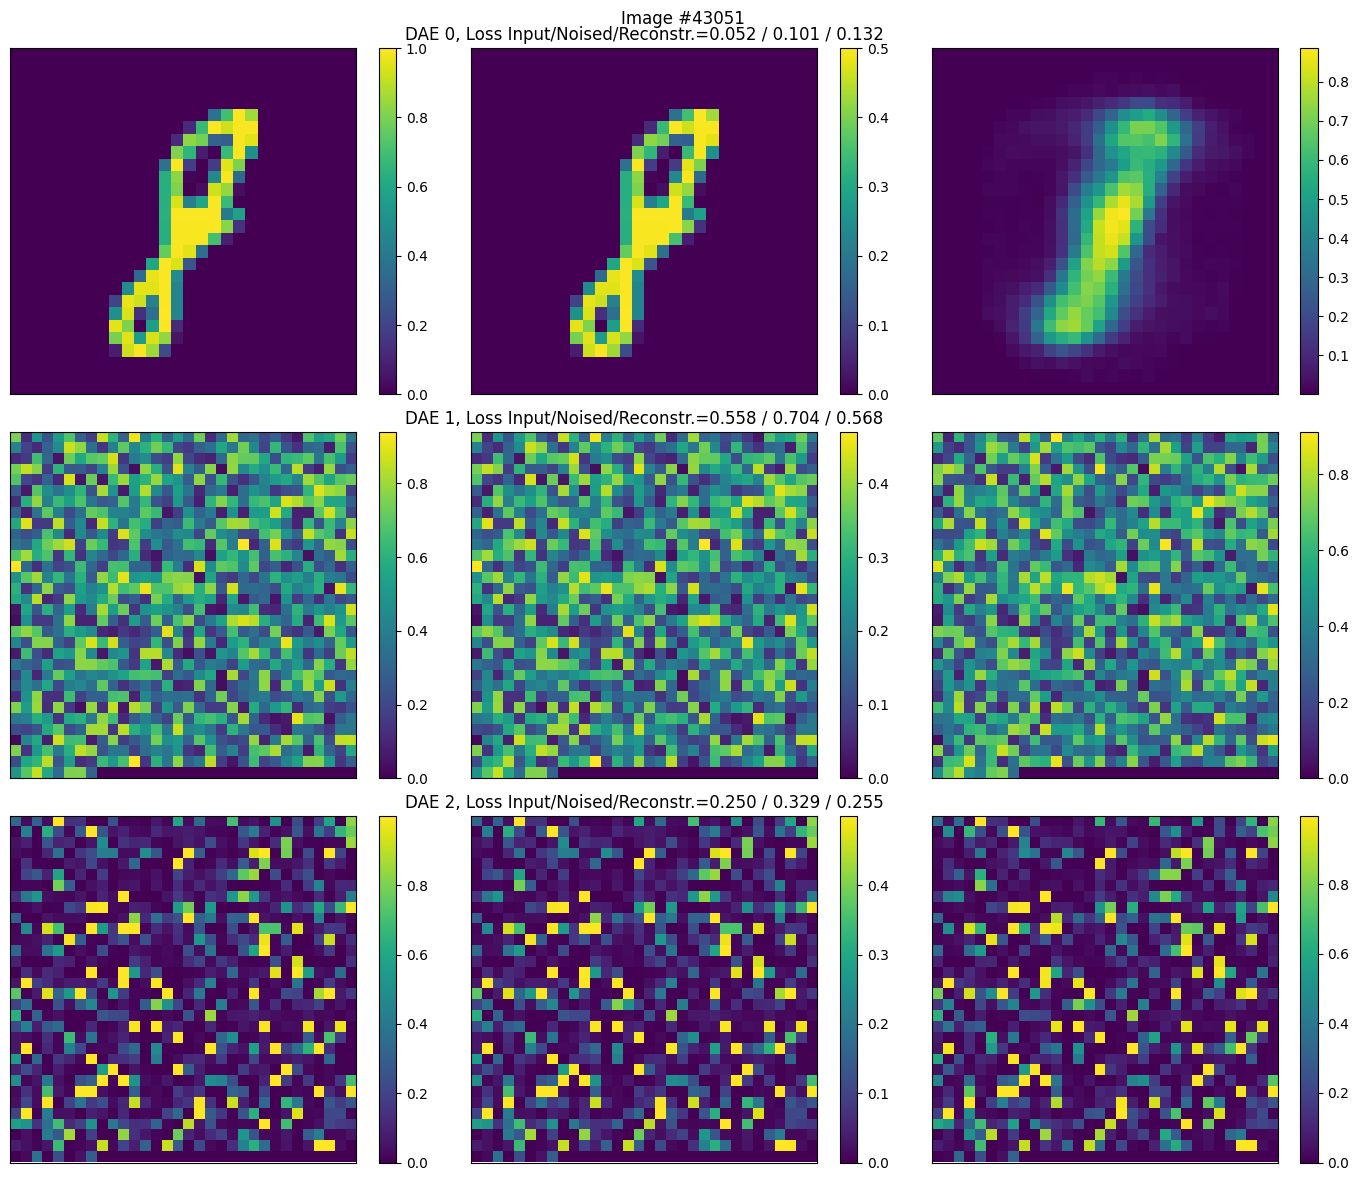

In [68]:
# @launchit.disable
fig, axes = plt.subplots(3, 3, subplot_kw={'yticks': [], 'xticks': []})
axes = axes.ravel()
fig.set_figwidth(14)
fig.set_figheight(4 * 3)

example_item_ind = RNG.choice(len(pretrain_dataset))
noise_func = noise_funcs[HP.pretraining.noise]
pretrain_model.eval()
loss_fn = losses[HP.pretraining.loss]()

with torch.no_grad():
    for target_dae_ind, base_ax_ind in zip(range(len(pretrain_model.daes)), range(len(axes))[::3]):
        batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
    
        for i in range(target_dae_ind):
            batch = pretrain_model.daes[i].encode(batch)

        noised = noise_func(batch)
        fr = pretrain_model.daes[target_dae_ind](noised)
        reconstructed = fr.reconstructed.to(device='cpu').detach()
        activations = fr.activations.to(device='cpu').detach()
        noised = fr.noised.to(device='cpu').detach()
        noised = noised / fr.noised_scale_factor
        batch = batch.to(device='cpu')

        ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]

        im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax1)
        im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax2)
        im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax3)
        loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
        loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
        loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
        ax2.set_title(f'DAE {target_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
        
fig.suptitle(f'Image #{example_item_ind}');
fig.tight_layout()

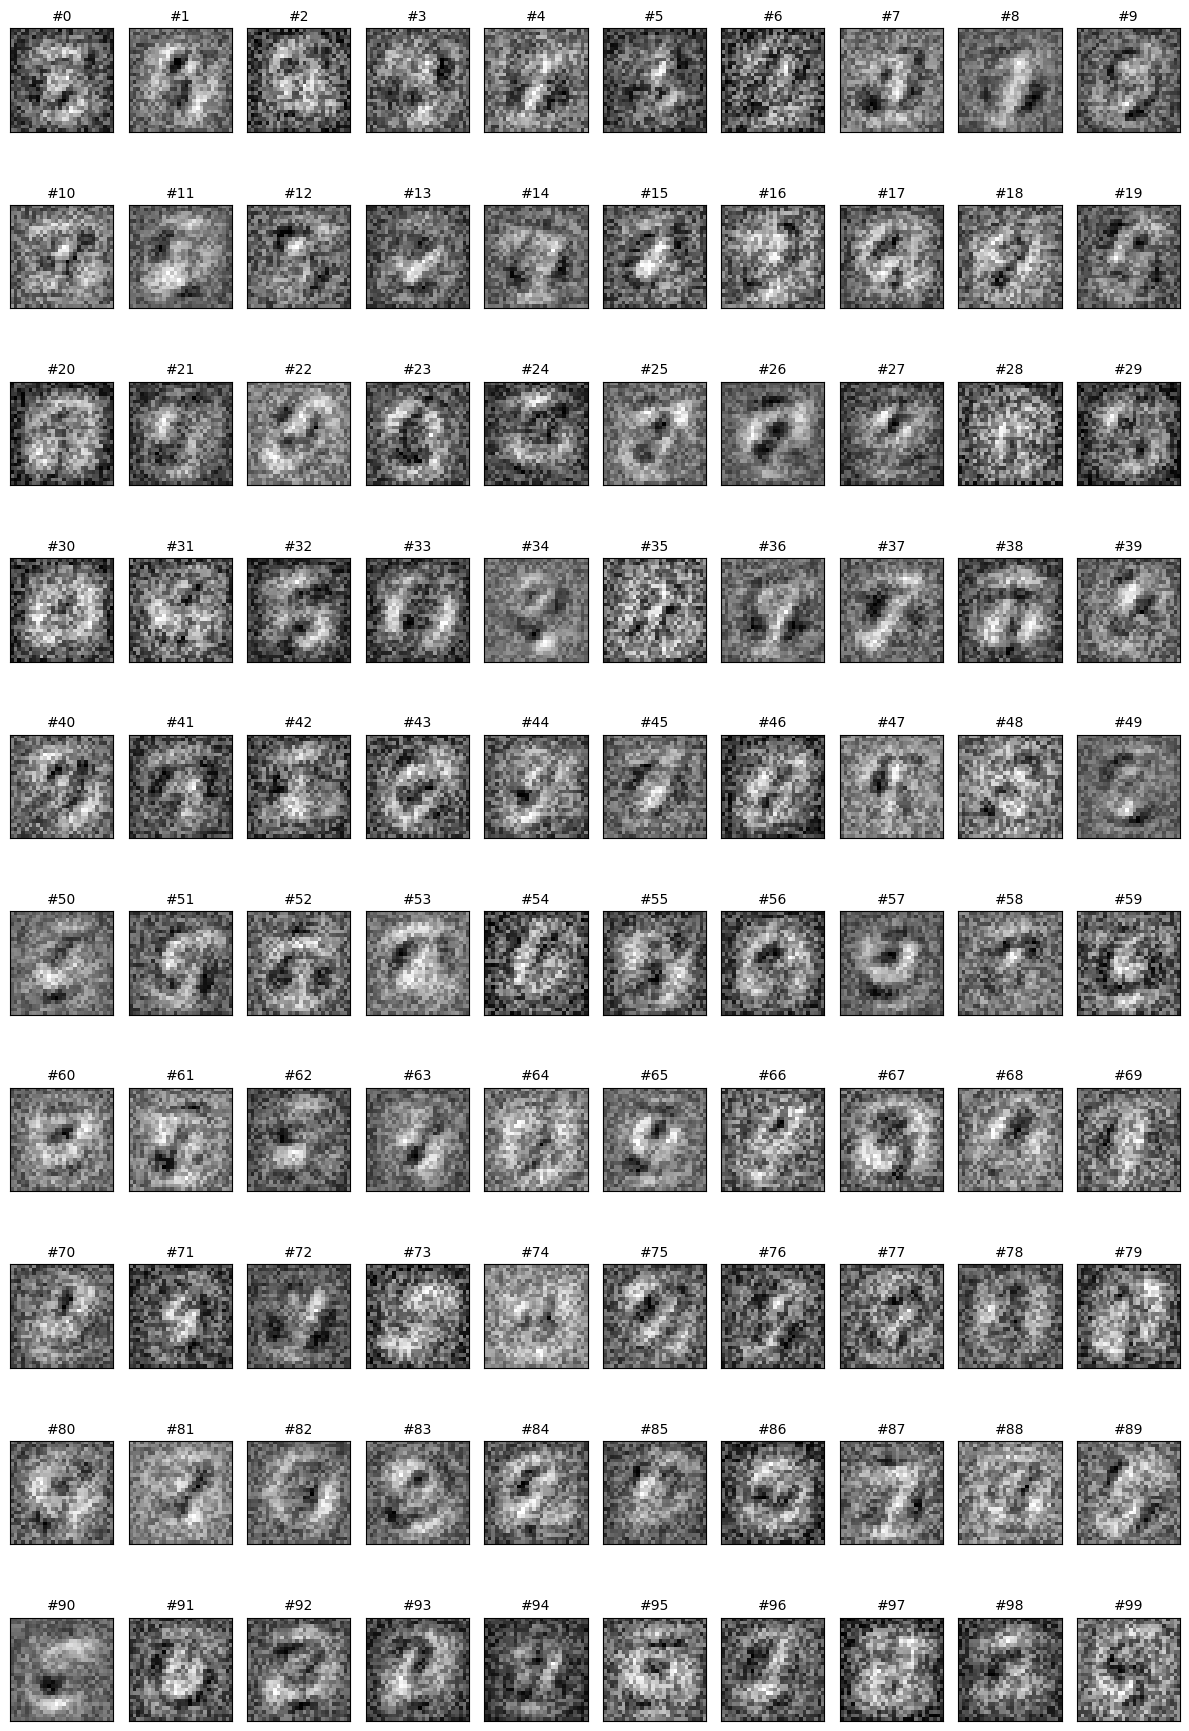

In [69]:
# @launchit.disable
bases_in_row = 10
max_filters_to_show = 100
fig, axes = plt.subplots(
    int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
    bases_in_row,
    subplot_kw={'yticks': [], 'xticks': []}
)
fig.set_figwidth(12)
fig.set_figheight(18)

weights = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()

if pretrain_model.daes[0].encoder.bias is not None:
    biases = pretrain_model.daes[0].encoder.bias.to(device='cpu').detach()
    filters = (weights.T + biases).T
else:
    filters = weights

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(f), cmap='gray')

plt.tight_layout()

# Supervised training via cross-validation

Alternatively, as illustrated in Figure 4, a logistic regression layer can be added on top of the encoders, yielding a deep neural network amenable to supervised learning. The parameters of **all layers** can then be **simultaneously fine-tuned** using a gradient-based procedure such as stochastic gradient descent. 

## Dataset

In [70]:
train_dataset, test_dataset = create_dataset_couple_for_supervised_training()

## Load pretrained model

In [71]:
# @launchit.disable_1
if HP.override_pretrain_model_version is not None:
    model_registry = new_model_registry()
    meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_GOAL.model_name, HP.override_pretrain_model_version, asset_ext='json', asset_classifier='meta')))
    old_hp = Hyperparameters.from_dict(meta['hypers'])
    LOG(pprint.pformat(old_hp._asdict(), sort_dicts=False))
    pretrain_model = StackedDAE(train_dataset.datasets[0].shape[1], old_hp.pretrain_model)
    pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
    pt_data = model_registry.get_asset_content(LAUNCH_GOAL.model_name, HP.override_pretrain_model_version, asset_ext='pt', asset_classifier='pretrain')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
    LOG(f'Pretrain model instance loaded for version={HP.override_pretrain_model_version}')

## Training via cross-validation

In [74]:
# @launchit.disable
# @launchit.collect_1
HP.training.batch_size = 100
HP.training.epochs_count = 1
HP.training.optimizer = 'Adam'
HP.training.learn_rate = 0.001
HP.training.cv_folds_count = 5
# @launchit.stop
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'hid_dropout': 0.5,
                    'inp_dropout': 0.5,
                    'is_bias': False,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 1,
                 'learn_rate': 0.005,
                 'loss': 'BCE',
                 'noise': 'None',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': 82,
 'training': {'batch_size': 100,
              'cv_folds_count': 5,
              'epochs_count': 1,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}


In [75]:
# @launchit.disable_1
classes_count = 10
assert torch.all(train_dataset.datasets[1].unique() == torch.arange(classes_count))
k_fold = KFold(HP.training.cv_folds_count, shuffle=True, random_state=HP.random_seed)
metrics_suite = defaultdict(list)
optuna_trial = optuna_multiprocessing.get_trial()

for fold_ind, (train_inds, val_inds) in tqdm(enumerate(k_fold.split(train_dataset)), desc='Fold', total=HP.training.cv_folds_count, disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('FOLD', fold_ind):
        data_loader = DataLoader(StackDataset(*train_dataset[train_inds]), batch_size=HP.training.batch_size, shuffle=True)
        val_images = train_dataset[val_inds][0].to(device=CONFIG.cuda_device)
        val_labels = train_dataset[val_inds][1].to(device=CONFIG.cuda_device)
        model = DeepLinearRegression(copy.deepcopy(pretrain_model), classes_count)
        model = model.to(device=CONFIG.cuda_device)
        loss_fn = tnn.CrossEntropyLoss()
        optimizer = getattr(topt, HP.training.optimizer)(model.parameters(), lr=HP.training.learn_rate)
        fold_metrics_suite = defaultdict(list)
    
        for epoch_ind in tqdm(range(HP.training.epochs_count), 'Epoch', disable=not CONFIG.is_interactive):
            epoch = epoch_ind + 1
            
            with LOG.auto_prefix('EPOCH', epoch):
                train_loss_sum, train_loss_denom = 0, 0
                train_accuracy_sum, train_accuracy_denom = 0, 0
                
                for batch in data_loader:
                    optimizer.zero_grad()
                    
                    images = batch[0].to(device=CONFIG.cuda_device)
                    labels = batch[1].to(device=CONFIG.cuda_device)
                    logits = model(images)
                    loss = loss_fn(logits, labels)
                    loss.backward()
                    
                    optimizer.step()
                    
                    train_loss_sum += loss.item() * len(batch)
                    train_loss_denom += len(batch)
                    train_accuracy_sum += (logits.argmax(axis=1) == labels).sum().item() # how many correct predictions
                    train_accuracy_denom += len(labels)
            
                assert train_loss_denom > 0
                assert train_accuracy_denom > 0
                train_loss = train_loss_sum / train_loss_denom
                train_accuracy = train_accuracy_sum / train_accuracy_denom
                fold_metrics_suite['train_loss'].append(train_loss)
                fold_metrics_suite['train_accuracy'].append(train_accuracy)
            
                with torch.no_grad():
                    val_logits = model(val_images)
                    val_loss = loss_fn(val_logits, val_labels).item()
                    predicted_val_labels = val_logits.argmax(axis=1)
                    val_accuracy = (predicted_val_labels == val_labels).sum().item() / len(val_labels)
                    fold_metrics_suite['val_loss'].append(val_loss)
                    fold_metrics_suite['val_accuracy'].append(val_accuracy)

                LOG(f'{train_loss=}, {train_accuracy=}, {val_loss=}, {val_accuracy=}', when=not CONFIG.is_interactive)
                
                if optuna_trial is not None and fold_ind == 0:
                    # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
                    # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
                    # > and the reported values from the second time are ignored.
                    # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
                    # As such only the first fold is indicative
                    optuna_trial.report(val_accuracy, epoch_ind) # "Note that pruners assume that step starts at zero" -> as such use epoch_ind instead of epoch
            
                    if optuna_trial.should_prune():
                        # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                        # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                        # pruner decision. As such cache pruning result so it's immutable
                        optuna_trial.set_user_attr('IS_PRUNED', True)
                        break
    
        for metric_name, metric_values in fold_metrics_suite.items():
            metrics_suite[metric_name].append(metric_values)
    
        if 'IS_PRUNED' in getattr(optuna_trial, 'user_attrs', {}):
            LOG(f'Optuna pruning condition encountered. Stopping training')
            break
    
for metric_name in list(metrics_suite.keys()):
    metric_values = metrics_suite[metric_name]
    metric_values = np.array(metric_values)
    # According to Optuna docs we could get pruned only on first fold (report() calls is ignored on successive folds).
    # As such we either should have 1) a full-fledged metrcs_suite (for all folds and for each epoch)
    # or 2) only metrics from the very first fold
    if 'IS_PRUNED' in getattr(optuna_trial, 'user_attrs', {}):
        assert len(metric_values) == 1
        assert metric_values.shape[1] <= HP.training.epochs_count
    else:
        assert len(metric_values) == HP.training.cv_folds_count
        assert metric_values.shape[1] == HP.training.epochs_count
        
    mean_values = list(metric_values.mean(axis=0)) # coercing to list since json.dump throws "np.ndarray is not serializable"
    std_values = list(metric_values.std(axis=0)) # coercing to list since json.dump throws "np.ndarray is not serializable"
    metrics_suite['mean_' + metric_name] = mean_values
    metrics_suite['std_' + metric_name] = std_values
    assert len(mean_values) == len(std_values)
    
    for epoch_ind in range(min(HP.training.epochs_count, len(mean_values))):
        epoch = epoch_ind + 1
        summary_writer.add_scalar('mean_' + metric_name, mean_values[epoch_ind], epoch)
        summary_writer.add_scalar('std_' + metric_name, std_values[epoch_ind], epoch)
        
    summary_writer.flush()   

METRICS_SUITE.update(metrics_suite)

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

## Save

In [76]:
# @launchit.disable_1
if LAUNCH_GOAL.goal in [LaunchGoal.E2E]:
    model_registry = new_model_registry()
    
    with io.BytesIO() as b:
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'hypers': HP._asdict(),
        }, b)
        model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='train', replace=True)
    
    with io.StringIO() as b:
        json.dump(METRICS_SUITE, b)
        model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

# Supervised training for test_accuracy

## Dataset

In [77]:
train_dataset, test_dataset = create_dataset_couple_for_supervised_training()

## Load pretrained hypers, model, metrics

In [78]:
if LAUNCH_GOAL.goal == LaunchGoal.TEST_ACCURACY:
    model_registry = new_model_registry()
    
    meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='json', asset_classifier='meta')))

    if model_registry.is_asset_present(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='pt', asset_classifier='train'):
        HP = Hyperparameters.from_dict(meta['hypers'])
        LOG(f'All hyperparameters loaded for version={LAUNCH_GOAL.model_version}: {HP._asdict()}')
    else:
        old_hp = Hyperparameters.from_dict(meta['hypers'])
        HP.pretrain_model = old_hp.pretrain_model
        LOG(f'Hyperparameters for pretrain model loaded for version={LAUNCH_GOAL.model_version}: {HP._asdict()}')
        
    pretrain_model = StackedDAE(train_dataset.datasets[0].shape[1], HP.pretrain_model)
    pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
    pt_data = model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='pt', asset_classifier='pretrain')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
    LOG(f'Pretrain model instance loaded for version={LAUNCH_GOAL.model_version}')

    old_metrics_suite = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='json', asset_classifier='metrics')))
    METRICS_SUITE.update(old_metrics_suite)
    LOG(f'Metrics suite loaded for version={LAUNCH_GOAL.model_version}')

## Training on whole dataset (test_accuracy)

In [79]:
# @launchit.disable_2
classes_count = 10
assert torch.all(train_dataset.datasets[1].unique() == torch.arange(classes_count))
data_loader = DataLoader(train_dataset, batch_size=HP.training.batch_size, shuffle=True)
test_images = test_dataset.datasets[0].to(device=CONFIG.cuda_device)
test_labels = test_dataset.datasets[1].to(device=CONFIG.cuda_device)
model = DeepLinearRegression(copy.deepcopy(pretrain_model), classes_count)
model = model.to(device=CONFIG.cuda_device)
loss_fn = tnn.CrossEntropyLoss()
optimizer = getattr(topt, HP.training.optimizer)(model.parameters(), lr=HP.training.learn_rate)

for epoch_ind in tqdm(range(HP.training.epochs_count), 'Epoch', disable=not CONFIG.is_interactive):
    epoch = epoch_ind + 1
    train_loss_sum, train_loss_denom = 0, 0
    train_accuracy_sum, train_accuracy_denom = 0, 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        images = batch[0].to(device=CONFIG.cuda_device)
        labels = batch[1].to(device=CONFIG.cuda_device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        
        optimizer.step()
        
        train_loss_sum += loss.item() * len(batch)
        train_loss_denom += len(batch)
        train_accuracy_sum += (logits.argmax(axis=1) == labels).sum().item() # how many correct predictions
        train_accuracy_denom += len(labels)

    assert train_loss_denom > 0
    assert train_accuracy_denom > 0
    train_loss = train_loss_sum / train_loss_denom
    train_accuracy = train_accuracy_sum / train_accuracy_denom
    summary_writer.add_scalar('train_loss', train_loss, epoch)
    summary_writer.add_scalar('train_accuracy', train_accuracy, epoch)
    METRICS_SUITE['train_loss'].append(train_loss)
    METRICS_SUITE['train_accuracy'].append(train_accuracy)

    with torch.no_grad():
        test_logits = model(test_images)
        test_loss = loss_fn(test_logits, test_labels).item()
        predicted_test_labels = test_logits.argmax(axis=1)
        test_accuracy = (predicted_test_labels == test_labels).sum().item() / len(test_labels)
        summary_writer.add_scalar('test_loss', test_loss, epoch)
        summary_writer.add_scalar('test_accuracy', test_accuracy, epoch)
        METRICS_SUITE['test_loss'].append(test_loss)
        METRICS_SUITE['test_accuracy'].append(test_accuracy)
        
    summary_writer.flush()

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

## Save

In [80]:
# @launchit.disable_2
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='full_train', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

# Publish trial result

In [121]:
# @launchit.disable_1
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling model')
        optuna_multiprocessing.save_trial_result(0)
    else:
        match LAUNCH_GOAL.goal:
            case LaunchGoal.PRETRAIN_LOSS:
                last_pretrain_losses = []
                
                for i in range(HP.pretrain_model.daes_count):
                    last_pretrain_losses.append(METRICS_SUITE[f'pretrain_loss_{i}'][-1])

                last_pretrain_losses = tuple(last_pretrain_losses)
                optuna_multiprocessing.save_trial_result(last_pretrain_losses)
                LOG(f'Pretrain objective result={last_pretrain_losses}')
            case LaunchGoal.E2E:
                last_std_val_accuracy = METRICS_SUITE['std_val_accuracy'][-1]
                last_mean_val_accuracy = METRICS_SUITE['mean_val_accuracy'][-1]
                    
                if last_std_val_accuracy > 0.05:
                    LOG(f'Unstable condition encountered: {last_mean_val_accuracy=}, {last_std_val_accuracy=}. Cancelling model')
                    optuna_multiprocessing.save_trial_result(0)
                else:
                    optuna_multiprocessing.save_trial_result(last_mean_val_accuracy)
                    LOG(f'Train objective result={last_mean_val_accuracy}')
            case _:
                assert False, f'Unsupported {LAUNCH_GOAL.exec_goal=}'

# Launch creation

## Manual for pretraining

In [83]:
# @launchit.disable
launchit_t0 = time.time()

In [86]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL='pretrain_loss',
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[2])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=412
Creating /home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch412.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch412.ipynb"


## Manual for e2e

In [25]:
# @launchit.disable
launchit_t0 = time.time()

In [11]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL='e2e',
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[2])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=263
Creating /home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch263.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch263.ipynb"


## Manual for test accuracy

In [11]:
# @launchit.disable
launchit_t0 = time.time()

In [12]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    # model_version = 262 # specify desired model version here
    # model_version = 330 # specify desired model version here
    # model_version = 326 # specify desired model version here
    model_version = 387 # specify desired model version here
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL='test_accuracy',
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch387.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch387.ipynb"


## Optuna (model selection)

### Template "PRETRAIN_LOSS"

In [ ]:
# @launchit.disable
# @launchit.collect_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    HP.random_seed = optuna_trial.suggest_categorical('random_seed', [3, 7, 42, 82, 100, 1945])
    
    HP.images.preprocessing = 'UNINORM'
    
    HP.pretrain_model.daes_count = 3
    HP.pretrain_model.filters_count = 1000
    HP.pretrain_model.is_tied_weights = True
    HP.pretrain_model.is_bias = True
    HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
    HP.pretrain_model.inp_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    HP.pretrain_model.hid_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    
    HP.pretraining.batch_size = 1000
    HP.pretraining.epochs_count = 300
    HP.pretraining.noise = 'None'
    HP.pretraining.optimizer = 'Adam'
    HP.pretraining.learn_rate = optuna_trial.suggest_float('pretraining.learn_rate', 0.004, 0.006)
    HP.pretraining.loss = 'BCE'
    HP.pretraining.regularization = None
    
    HP.training.batch_size = 500
    HP.training.epochs_count = 0
    HP.training.optimizer = 'Adam'
    HP.training.learn_rate = 1
    HP.training.cv_folds_count = 5

### Template "E2E"

In [ ]:
# optuna_trial = optuna_multiprocessing.get_trial()

# if optuna_trial is not None:
#     HP.random_seed = optuna_trial.suggest_categorical('random_seed', [3, 7, 42, 82, 100, 1945])
    
#     HP.images.preprocessing = 'UNINORM'
    
#     HP.pretrain_model.daes_count = 3
#     HP.pretrain_model.filters_count = 1000
#     HP.pretrain_model.is_tied_weights = True
#     HP.pretrain_model.is_bias = True
#     HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
#     HP.pretrain_model.inp_dropout = 0.5 # analog to 'Masking_0.5', but much faster
#     HP.pretrain_model.hid_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    
#     HP.pretraining.batch_size = 1000
#     HP.pretraining.epochs_count = 300
#     HP.pretraining.noise = 'None'
#     HP.pretraining.optimizer = 'Adam'
#     HP.pretraining.learn_rate = optuna_trial.suggest_float('pretraining.learn_rate', 0.005, 0.05)
#     HP.pretraining.loss = 'BCE'
#     HP.pretraining.regularization = None
    
#     HP.training.batch_size = 500
#     HP.training.epochs_count = optuna_trial.suggest_int('training.epochs_count', 50, 300, step=50)
#     HP.training.optimizer = 'Adam'
#     HP.training.learn_rate = optuna_trial.suggest_float('training.learn_rate', 0.0001, 0.1)
#     HP.training.cv_folds_count = 5

In [ ]:
# optuna_trial = optuna_multiprocessing.get_trial()

# if optuna_trial is not None:
#     HP.images.preprocessing = 'UNINORM'
    
#     HP.pretrain_model.daes_count = 3
#     HP.pretrain_model.filters_count = 1000
#     HP.pretrain_model.is_tied_weights = True
#     HP.pretrain_model.is_bias = True
#     HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
#     HP.pretrain_model.inp_dropout = 0.2
#     HP.pretrain_model.hid_dropout = 0.5
    
#     HP.pretraining.batch_size = 500
#     HP.pretraining.epochs_count = 0
#     HP.pretraining.noise = 'None'
#     HP.pretraining.optimizer = 'Adam'
#     HP.pretraining.learn_rate = 0.001
#     HP.pretraining.loss = 'BCE'
#     HP.pretraining.regularization = None

#     HP.random_seed = optuna_trial.suggest_categorical('random_seed', [7, 42, 82, 100, 1945])
#     HP.override_pretrain_model_version = 71
    
#     HP.training.batch_size = 500
#     HP.training.epochs_count = optuna_trial.suggest_int('training.epochs_count', 50, 300, step=50)
#     HP.training.optimizer = 'Adam'
#     HP.training.learn_rate = optuna_trial.suggest_float('training.learn_rate', 0.0001, 0.1)
#     HP.training.cv_folds_count = 5

In [ ]:
# optuna_trial = optuna_multiprocessing.get_trial()

# if optuna_trial is not None:
#     HP.random_seed = optuna_trial.suggest_categorical('random_seed', [7, 42, 82, 100, 1945])
    
#     HP.images.preprocessing = 'UNINORM'
    
#     HP.pretrain_model.daes_count = 3
#     HP.pretrain_model.filters_count = 1000
#     HP.pretrain_model.is_tied_weights = True
#     HP.pretrain_model.is_bias = True
#     HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
#     HP.pretrain_model.inp_dropout = 0.5
#     HP.pretrain_model.hid_dropout = 0.5
    
#     HP.pretraining.batch_size = 1000
#     HP.pretraining.epochs_count = 300
#     HP.pretraining.noise = 'None'
#     HP.pretraining.optimizer = 'Adam'
#     HP.pretraining.learn_rate = optuna_trial.suggest_float('pretraining.learn_rate', 0.005, 0.05)
#     HP.pretraining.loss = 'BCE'
#     HP.pretraining.regularization = None
    
#     HP.training.batch_size = 500
#     HP.training.epochs_count = 0
#     HP.training.optimizer = 'Adam'
#     HP.training.learn_rate = 0.001
#     HP.training.cv_folds_count = 5

### Unleash

In [8]:
# @launchit.disable
def get_optimize_directions(LAUNCH_GOAL):
    match LAUNCH_GOAL:
        case LaunchGoal.PRETRAIN_LOSS:
            return ['minimize'] * 3
        case LaunchGoal.E2E:
            return ['maximize']
        case _:
            assert False, f'Unsupported {LAUNCH_GOAL=}'

LAUNCH_GOAL = LaunchGoal.PRETRAIN_LOSS
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=LAUNCH_GOAL.value,
)
# study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}'
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_v3'
# study_name = CONFIG.self_name + '_e2e_2'
# study_name = CONFIG.self_name + '_supervised_over_71'
# study_name = CONFIG.self_name + '_pretraining2'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[2],
    run_path=CONFIG.run_path,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(LAUNCH_GOAL),
)
rop_tasks = [rop_task] * 40
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

[I 2026-02-01 21:39:11,925] A new study created in Journal with name: s3_stacked_dae_09_pretrain_loss_v3
[I 2026-02-01 21:39:11,927] Using an existing study with name 's3_stacked_dae_09_pretrain_loss_v3' instead of creating a new one.
[I 2026-02-01 21:39:11,932] Using an existing study with name 's3_stacked_dae_09_pretrain_loss_v3' instead of creating a new one.
[I 2026-02-01 21:39:11,941] Using an existing study with name 's3_stacked_dae_09_pretrain_loss_v3' instead of creating a new one.
[I 2026-02-01 21:44:50,996] Trial 1 finished with values: [0.08846611343324184, 0.11844095923006534, 0.05955107907454173] and parameters: {'random_seed': 7, 'pretraining.learn_rate': 0.004167582668582042}.
[I 2026-02-01 21:44:51,068] Using an existing study with name 's3_stacked_dae_09_pretrain_loss_v3' instead of creating a new one.
[I 2026-02-01 21:45:07,492] Trial 0 finished with values: [0.08843227848410606, 0.1172455416371425, 0.05714435080687205] and parameters: {'random_seed': 100, 'pretrainin

In [9]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")

[I 2026-02-01 22:55:59,249] Using an existing study with name 's3_stacked_dae_09_pretrain_loss_v3' instead of creating a new one.


Study statistics: 
	Number of finished trials: 40
	Number of pruned trials: 0
	Number of complete trials: 40
Number of trials on the Pareto front: 6
Trial with lowest loss_0:
	number: 26
	mver: 387
	params: {'random_seed': 42, 'pretraining.learn_rate': 0.005492061413625679}
	values: [0.08833594769239425, 0.11375552080571652, 0.056806695212920505]
Trial with lowest loss_1:
	number: 5
	mver: 366
	params: {'random_seed': 7, 'pretraining.learn_rate': 0.005999620308115563}
	values: [0.08838711865246296, 0.1107913492868344, 0.0565817362939318]
Trial with lowest loss_2:
	number: 33
	mver: 394
	params: {'random_seed': 42, 'pretraining.learn_rate': 0.005927765975396279}
	values: [0.08837893058856329, 0.11239499002695083, 0.054594331855575245]


In [31]:
# @launchit.disable
train_images, _ = get_mnist_images('TRAIN')
model_registry = new_model_registry(is_real=True)
meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='json', asset_classifier='meta')))
old_hp = Hyperparameters.from_dict(meta['hypers'])
LOG(pprint.pformat(old_hp._asdict(), sort_dicts=False))

pretrain_model = StackedDAE(train_images.shape[1], old_hp.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
pt_data = model_registry.get_asset_content(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, asset_ext='pt', pretrain_stacked_dae_asset_classifier)
pt_data = io.BytesIO(initial_bytes=pt_data)
checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))

if pretrain_stacked_dae_asset == 'pretrain_pt':
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
elif pretrain_stacked_dae_asset == 'train_pt':
    fined_tuned_model = DeepLinearRegression(pretrain_model, 10)
    fined_tuned_model.load_state_dict(checkpoint['model_state_dict']) # implicit load of pretrain model
else:
    assert False, pretrain_stacked_dae_asset
    
pretrain_model.eval()

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 300,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': None,
 'training': {'batch_size': 1000,
              'epochs_count': 500,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}


StackedDAE(
  (daes): ModuleList(
    (0): DenoiseAutoencoder(
      (encoder): Linear(in_features=784, out_features=1000, bias=True)
    )
    (1-2): 2 x DenoiseAutoencoder(
      (encoder): Linear(in_features=1000, out_features=1000, bias=True)
    )
  )
)

## Train & test datasets

In [32]:
# @launchit.disable
def create_dataset_for_classification(images, image_labels, model, encode_depth=-1):
    features_list = []
    labels_list = []
    assert len(images) == len(image_labels)
    data_loader = DataLoader(list(zip(torch.Tensor(images), image_labels)), batch_size=100)
    
    for images, labels in tqdm(data_loader, disable=not CONFIG.is_interactive):
        images = torch.Tensor(images).to(device=CONFIG.cuda_device)
        
        with torch.no_grad():
            features = model.encode(images, encode_depth)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    x = np.vstack(features_list).astype('float64') # float64 is recommended for SVC
    y = np.hstack(labels_list)
    return x, y

In [44]:
# @launchit.disable
encode_depth = 3

train_images, train_image_labels = get_mnist_images('TRAIN')
train_images, train_images_scaler = preprocess_images(train_images, HP.images.preprocessing)
x_train, y_train = create_dataset_for_classification(train_images, train_image_labels, pretrain_model, encode_depth)

test_images, test_image_labels = get_mnist_images('TEST')
test_images, _ = preprocess_images(test_images, HP.images.preprocessing, train_images_scaler) # train_images_scaler is a must!!!
x_test, y_test = create_dataset_for_classification(test_images, test_image_labels, pretrain_model, encode_depth)

  0%|          | 0/600 [00:00<?, ?it/s]